In [34]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report,accuracy_score
from sklearn.metrics import confusion_matrix


In [2]:
df=pd.read_json("news_dataset.json")
print(df.shape)

(12695, 2)


In [3]:
df.head()

,text,category
0,Watching Schrödinger's Cat Die University of C...,SCIENCE
1,WATCH: Freaky Vortex Opens Up In Flooded Lake,SCIENCE
2,Entrepreneurs Today Don't Need a Big Budget to...,BUSINESS
3,These Roads Could Recharge Your Electric Car A...,BUSINESS
4,Civilian 'Guard' Fires Gun While 'Protecting' ...,CRIME


In [4]:
df.category.value_counts()

category
BUSINESS    4254
SPORTS      4167
CRIME       2893
SCIENCE     1381
Name: count, dtype: int64

In [5]:
df_business = df[df.category == "BUSINESS"]  
df_sports = df[df.category == "SPORTS"]
df_crime = df[df.category == "CRIME"]        
df_science = df[df.category == "SCIENCE"] 

In [6]:
df_all = pd.concat([df_business, df_sports, df_crime, df_science], axis=0)
print("Class distribution BEFORE SMOTE:")
print(df_all.category.value_counts())

Class distribution BEFORE SMOTE:
category
BUSINESS    4254
SPORTS      4167
CRIME       2893
SCIENCE     1381
Name: count, dtype: int64


In [7]:
target = {'BUSINESS': 0, 'SPORTS': 1, 'CRIME': 2, 'SCIENCE': 3}
df_all['category_num'] = df_all['category'].map(target)

In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    df_all['text'], 
    df_all['category_num'],
    test_size=0.2,
    random_state=2022,
    stratify=df_all['category_num'] 
)

In [9]:
print(f"\nX_train shape: {X_train.shape}")
print(f"y_train distribution BEFORE SMOTE: {Counter(y_train)}")


X_train shape: (10156,)
y_train distribution BEFORE SMOTE: Counter({0: 3403, 1: 3334, 2: 2314, 3: 1105})


In [10]:
y_test.value_counts()

category_num
0    851
1    833
2    579
3    276
Name: count, dtype: int64

**Attempt 1 : Use 1-gram which is nothing but a Bag Of Words (BOW) model**

In [11]:
vectorizer =  CountVectorizer( ngram_range=(1,1), min_df=3, max_df=0.7,  max_features=15000)
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

In [12]:
smote = SMOTE(random_state=2022, sampling_strategy='auto')
X_train_smote, y_train_smote = smote.fit_resample(X_train_vectorized, y_train)

In [13]:
print(f"\ny_train distribution AFTER SMOTE: {Counter(y_train_smote)}")



y_train distribution AFTER SMOTE: Counter({0: 3403, 1: 3403, 3: 3403, 2: 3403})


In [14]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train_smote, y_train_smote)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [15]:
y_pred = model.predict(X_test_vectorized)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['BUSINESS', 'SPORTS', 'CRIME', 'SCIENCE']))


Accuracy: 0.8937

Classification Report:
              precision    recall  f1-score   support

    BUSINESS       0.90      0.90      0.90       851
      SPORTS       0.92      0.90      0.91       833
       CRIME       0.89      0.92      0.90       579
     SCIENCE       0.80      0.79      0.79       276

    accuracy                           0.89      2539
   macro avg       0.88      0.88      0.88      2539
weighted avg       0.89      0.89      0.89      2539



In [16]:
y_pred[:5]

array([1, 2, 1, 0, 2], dtype=int64)

In [17]:
y_test[:5]

11636    1
5347     2
5505     1
4533     0
3055     2
Name: category_num, dtype: int64

**Using pipeline**

In [18]:

clf = ImbPipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1, 1), min_df=3, max_df=0.7,  max_features=15000)),
    ('smote', SMOTE(random_state=2022, sampling_strategy='auto')),
    ('classifier', MultinomialNB())
])


clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
# Evaluate
print(classification_report(y_test, y_pred, 
                          target_names=['BUSINESS', 'SPORTS', 'CRIME', 'SCIENCE']))


Accuracy: 0.8937
              precision    recall  f1-score   support

    BUSINESS       0.90      0.90      0.90       851
      SPORTS       0.92      0.90      0.91       833
       CRIME       0.89      0.92      0.90       579
     SCIENCE       0.80      0.79      0.79       276

    accuracy                           0.89      2539
   macro avg       0.88      0.88      0.88      2539
weighted avg       0.89      0.89      0.89      2539



**Attempt 2 : Use 1-gram and bigrams**

In [20]:

clf = ImbPipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.7,  max_features=15000)),
    ('smote', SMOTE(random_state=2022, sampling_strategy='auto')),
    ('classifier', MultinomialNB())
])


clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
# Evaluate
print(classification_report(y_test, y_pred, 
                          target_names=['BUSINESS', 'SPORTS', 'CRIME', 'SCIENCE']))


Accuracy: 0.8921
              precision    recall  f1-score   support

    BUSINESS       0.89      0.91      0.90       851
      SPORTS       0.92      0.90      0.91       833
       CRIME       0.89      0.92      0.91       579
     SCIENCE       0.81      0.78      0.80       276

    accuracy                           0.89      2539
   macro avg       0.88      0.88      0.88      2539
weighted avg       0.89      0.89      0.89      2539



**Attempt 3 : Use 1-gram to trigrams**

In [21]:

clf = ImbPipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1,3 ), min_df=3, max_df=0.7,  max_features=15000)),
    ('smote', SMOTE(random_state=2022, sampling_strategy='auto')),
    ('classifier', MultinomialNB())
])


clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
# Evaluate
print(classification_report(y_test, y_pred, 
                          target_names=['BUSINESS', 'SPORTS', 'CRIME', 'SCIENCE']))


Accuracy: 0.8889
              precision    recall  f1-score   support

    BUSINESS       0.88      0.90      0.89       851
      SPORTS       0.93      0.89      0.91       833
       CRIME       0.89      0.92      0.90       579
     SCIENCE       0.80      0.78      0.79       276

    accuracy                           0.89      2539
   macro avg       0.87      0.87      0.87      2539
weighted avg       0.89      0.89      0.89      2539



### Use text pre-processing to remove stop words, punctuations and apply lemmatization

In [22]:
import spacy

nlp = spacy.load("en_core_web_sm") 

def preprocess(text):
    
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)
    
    return " ".join(filtered_tokens) 

In [24]:
df_all['preprocessed_txt'] = df_all['text'].apply(preprocess) 

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    df_all.preprocessed_txt, 
    df_all.category_num, 
    test_size=0.2, 
    random_state=2022,
    stratify=df_all.category_num
)

In [27]:
print(X_train.shape)
X_train.head()

(10156,)


306                           Brad Paterson push think big
10930    Salty Cardinals Fan burn Jason Heyward Jersey ...
5595     Google take Mindfulness Revolution Downunder h...
7781                astronomer Discover big thing Universe
12408    WWII Plane crash Hudson River attempt emergenc...
Name: preprocessed_txt, dtype: object

In [28]:
y_train.value_counts()

category_num
0    3403
1    3334
2    2314
3    1105
Name: count, dtype: int64

In [29]:
y_test.value_counts()

category_num
0    851
1    833
2    579
3    276
Name: count, dtype: int64

In [30]:

clf = ImbPipeline([
    ('vectorizer', CountVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.7,  max_features=15000)),
    ('smote', SMOTE(random_state=2022, sampling_strategy='auto')),
    ('classifier', MultinomialNB())
])


clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
# Evaluate
print(classification_report(y_test, y_pred, 
                          target_names=['BUSINESS', 'SPORTS', 'CRIME', 'SCIENCE']))


Accuracy: 0.9051
              precision    recall  f1-score   support

    BUSINESS       0.92      0.92      0.92       851
      SPORTS       0.93      0.91      0.92       833
       CRIME       0.88      0.93      0.91       579
     SCIENCE       0.82      0.80      0.81       276

    accuracy                           0.91      2539
   macro avg       0.89      0.89      0.89      2539
weighted avg       0.91      0.91      0.91      2539



In [33]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[780,  27,  24,  20],
       [ 21, 758,  36,  18],
       [ 22,   9, 539,   9],
       [ 27,  17,  11, 221]], dtype=int64)

Text(95.72222222222221, 0.5, 'Truth')

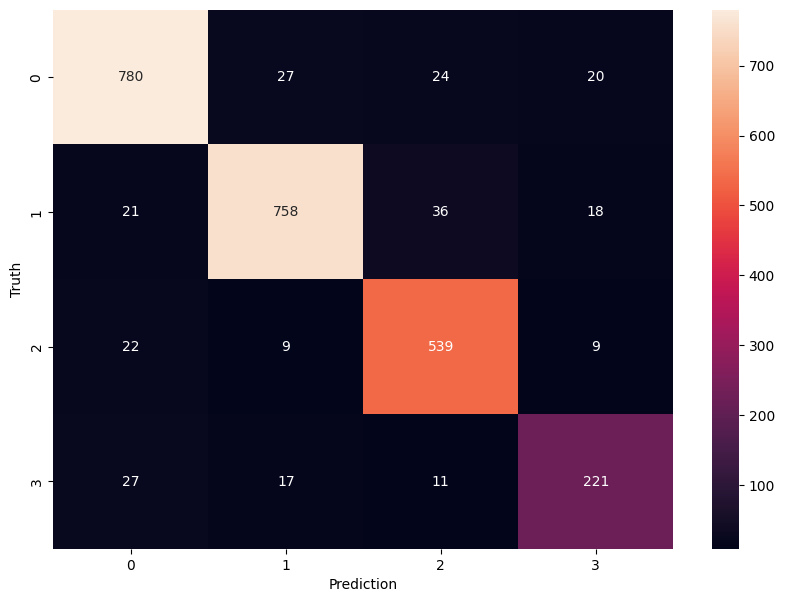

In [35]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')